In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from numpy import linalg 
from scipy.linalg import sqrtm
import plotly
from plotly.graph_objs import Surface
from numpy.linalg import eig, matrix_rank, inv
from vendi_score import vendi
from scipy.stats import entropy
from sklearn.metrics.pairwise import cosine_similarity
import yfinance as yf
from effectiverank import EffectiveRankCalculator

import math

from bs4 import BeautifulSoup # library to parse HTML documents

import requests
import os
from itertools import chain
import seaborn as sns
from datetime import datetime, timedelta

In [79]:
sectors = ['energy', 'materials', 'industrials', 'consumer_discretionary',\
           'consumer_staples', 'health_care', 'financials', 'information_technology',\
           'communication_services', 'utilities', 'real_estate']

models = ['gpt-3.5-turbo-0613', 'gpt-4', 'gpt-4-1106-preview', 'bard', 'claude']

In [80]:
def calculate_hhi(sector_name, portfolio):
    squared_weights = portfolio['Weight'].apply(lambda x: x**2)
    return squared_weights.sum()

In [81]:
for model in models:
    for sector_name in sectors:
        if model == 'gpt-4':
            csv_path = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == "gpt-4-1106-preview":
            csv_path = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'bard':
            csv_path = f'bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_path = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_path)
        index = calculate_hhi(sector_name, portfolio)

        with open('metrics/hhi.csv', 'a', encoding='utf-8') as f:
            f.write(f'{model},{sector_name},{index}\n')
    

In [7]:
def calculate_hhi(sector_name, portfolio):
    squared_weights = portfolio['Weight'].apply(lambda x: x**2)
    return squared_weights.sum()

In [8]:
calculate_hhi(sector_name, portfolio)

0.07813599999999997

$$
HHI = \sum_{i=1}^n s_i^2
$$

The bigger the index, the less difersified the portfolio is (more weight is assigned to particular companies). In my case, I am using the decimal numbers.

Examples in my case:

- one asset with 100% weught: HHI = 100
- 15 equally weighted assets: HHI = 6.67

In [9]:
df = pd.read_csv('metrics/hhi.csv')
df['index'] *= 100
df.sort_values(by='index')

,model,sector,index
101,gpt-4,industrials,6.838862
57,gpt-4,industrials,6.838862
13,gpt-4,industrials,6.838862
24,gpt-4-1106-preview,industrials,6.847929
112,gpt-4-1106-preview,industrials,6.847929
...,...,...,...
64,gpt-4,utilities,9.999200
108,gpt-4,utilities,9.999200
30,gpt-4-1106-preview,communication_services,10.732627
74,gpt-4-1106-preview,communication_services,10.732627


look at: risk contribution, risk parity


In [10]:
grouped = df.groupby(['model', 'sector']).mean()
grouped_df = grouped.reset_index()

# plt.figure(figsize=(12, 5))
# for category1, category1_group in grouped_df.groupby('model'):
#     plt.bar(category1_group['sector'], category1_group['index'], label=category1)

# plt.xlabel('sector')
# plt.ylabel('Average Value')
# plt.title('Grouped Bar Chart')
# plt.legend()
# plt.show()


## PCA

In [11]:
def perform_pca(sector_name, alpha=0):
    cevs = []

    for model in models:
        if model == 'gpt-4':
            csv_path = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == "gpt-4-1106-preview":
            csv_path = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'bard':
            csv_path =  f'bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_path = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_path)

        csv_path = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_out = pd.read_csv(csv_path)
        required_columns = portfolio['Stock'].tolist()
        returns_out_filtered = returns_out.loc[:, required_columns]
        
        print(f'Processing {sector_name.upper()} sector, {model.upper()} model portfolio')

        pca = PCA()
        pca.fit(returns_out_filtered)

        explained_variance_ratio = pca.explained_variance_ratio_
        print('Explained variance ratio: ', explained_variance_ratio)
        
        enb = 1 / np.sum(np.square(explained_variance_ratio))
        print("Effective number of bets: ", enb)

        cumulative_explained_variance = np.cumsum(explained_variance_ratio)
        cevs.append(cumulative_explained_variance)

    plt.figure(figsize=(8, 6))
    # for cumulative_explained_variance in cevs:
    #     plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o')


    for i, cumulative_explained_variance in enumerate(cevs):
        plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', label=models[i])

    plt.axhline(y=alpha, color='red', linestyle='--')

    plt.xlabel('Number of principal components')
    plt.ylabel('Cumulative explained variance ratio')
    plt.title(f'{sector_name} sector portfolio')
    plt.legend(models, loc='lower right')
    plt.show()

        # with open('metrics/pca.csv', 'a', encoding='utf-8') as f:
        #     f.write(f'{model},{sector_name},{enb}\n')



The Effective Number of Bets is the inverse of the sum of the squared normalized eigenvalues.

Processing ENERGY sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.65945192 0.09883558 0.05852572 0.03560373 0.02625975 0.02126954
 0.01770261 0.01671781 0.014542   0.01338656 0.01030661 0.00893876
 0.00742014 0.00671678 0.00432245]
Effective number of bets:  2.213522160856631
Processing ENERGY sector, GPT-4 model portfolio
Explained variance ratio:  [0.66914563 0.09524361 0.05747254 0.0338416  0.02604796 0.02075669
 0.01745532 0.01490724 0.01339231 0.0118467  0.00982753 0.0087155
 0.00821054 0.00702792 0.0061089 ]
Effective number of bets:  2.157226501100918
Processing ENERGY sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.66973987 0.09488139 0.05574981 0.0349229  0.026994   0.0209206
 0.0171669  0.01618232 0.01367061 0.0133343  0.00978832 0.00867537
 0.00730379 0.00638112 0.00428868]
Effective number of bets:  2.1539990490673255
Processing ENERGY sector, BARD model portfolio
Explained variance ratio:  [0.67942814 0.09082408 0.04852387 

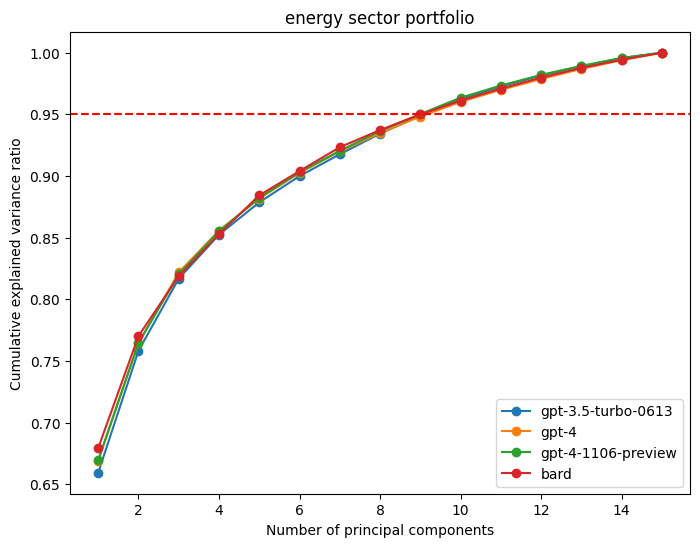

Processing MATERIALS sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.40360683 0.13118075 0.10269986 0.07731353 0.06788352 0.04547432
 0.03942588 0.0295331  0.02655478 0.02294715 0.01827945 0.01142871
 0.01043635 0.00853569 0.00470005]
Effective number of bets:  4.816154198217831
Processing MATERIALS sector, GPT-4 model portfolio
Explained variance ratio:  [0.43322534 0.13790153 0.09151268 0.07100973 0.05125131 0.0456475
 0.03473518 0.02958702 0.02346611 0.01955185 0.01782571 0.01335865
 0.01207731 0.0105575  0.00829257]
Effective number of bets:  4.373199604153316
Processing MATERIALS sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.41259409 0.12750291 0.09563049 0.07561091 0.06629032 0.04415786
 0.04067826 0.0316478  0.02718231 0.02085394 0.01783938 0.01244704
 0.0106351  0.00885988 0.0080697 ]
Effective number of bets:  4.711261751035249
Processing MATERIALS sector, BARD model portfolio
Explained variance ratio:  [0.42419999 0.11662612

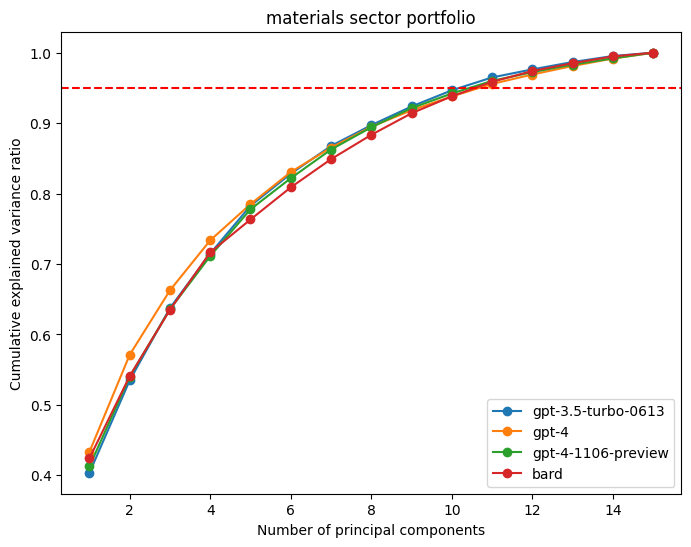

Processing INDUSTRIALS sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.42152968 0.10263318 0.08873151 0.06186984 0.05141967 0.04410209
 0.04232953 0.03350997 0.02981175 0.02811729 0.02261875 0.02220314
 0.01896564 0.01771175 0.01444621]
Effective number of bets:  4.7395232845479525
Processing INDUSTRIALS sector, GPT-4 model portfolio
Explained variance ratio:  [0.40216342 0.11674137 0.09535073 0.06014616 0.05815637 0.04946877
 0.04234324 0.03346022 0.03015613 0.02687245 0.02245942 0.02180382
 0.01874272 0.01474815 0.00738704]
Effective number of bets:  4.998753698301021
Processing INDUSTRIALS sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.40864857 0.12209061 0.08960378 0.06269702 0.05947611 0.04674837
 0.03917481 0.03236108 0.0311524  0.02583174 0.02432054 0.02141898
 0.01669432 0.01207029 0.00771138]
Effective number of bets:  4.870063749598714
Processing INDUSTRIALS sector, BARD model portfolio
Explained variance ratio:  [0.3821002  

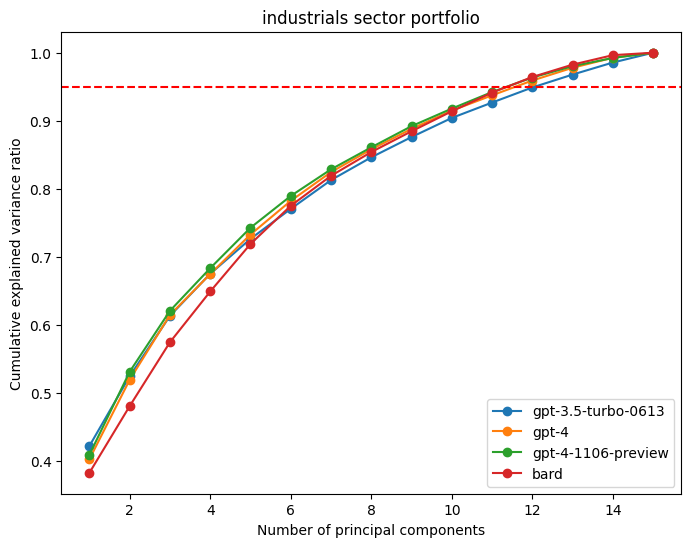

Processing CONSUMER_DISCRETIONARY sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.41083507 0.13361489 0.11786166 0.08762899 0.05476503 0.04328139
 0.03570262 0.02967447 0.0229243  0.02155146 0.01756914 0.01106994
 0.00515365 0.00435647 0.00401092]
Effective number of bets:  4.614266377577882
Processing CONSUMER_DISCRETIONARY sector, GPT-4 model portfolio
Explained variance ratio:  [0.34175204 0.15851296 0.13670401 0.07001996 0.05676591 0.05295321
 0.03548939 0.03288107 0.03173667 0.02818221 0.02080339 0.01439304
 0.00894097 0.00586762 0.00499753]
Effective number of bets:  5.667025612895023
Processing CONSUMER_DISCRETIONARY sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.36908988 0.15632308 0.13443902 0.06558179 0.05185324 0.04332029
 0.0398465  0.03508515 0.02512112 0.02304394 0.02070381 0.01423056
 0.01052616 0.00587852 0.00495695]
Effective number of bets:  5.197873704135974
Processing CONSUMER_DISCRETIONARY sector, BARD model portfo

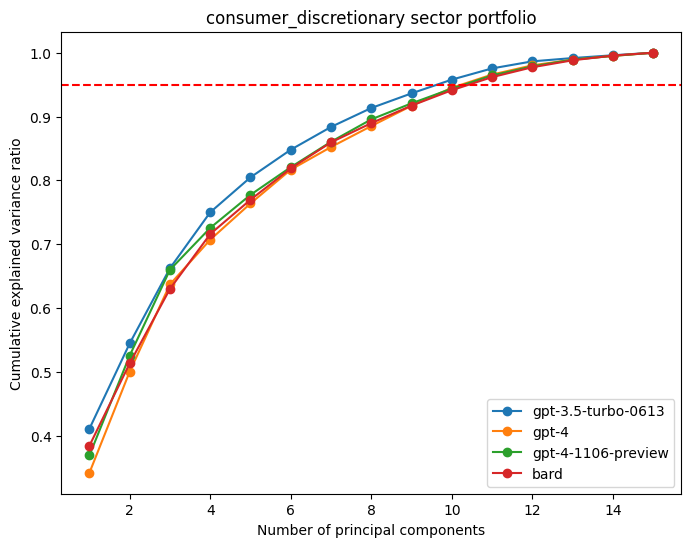

Processing CONSUMER_STAPLES sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.38482839 0.21810928 0.0770957  0.0622753  0.05527351 0.04674763
 0.03166435 0.02739638 0.02226585 0.0184213  0.01509326 0.01374849
 0.01152716 0.00940969 0.00614371]
Effective number of bets:  4.6730870626481975
Processing CONSUMER_STAPLES sector, GPT-4 model portfolio
Explained variance ratio:  [0.35897619 0.20866181 0.13343172 0.06211071 0.05174125 0.03738035
 0.03297626 0.02223026 0.02080937 0.0175561  0.01496557 0.01281608
 0.01145632 0.00875446 0.00613356]
Effective number of bets:  4.9727380075010945
Processing CONSUMER_STAPLES sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.3939137  0.24321413 0.06900802 0.06039559 0.05164563 0.03677243
 0.0303732  0.02368801 0.02062649 0.01716275 0.01445363 0.01225194
 0.01108353 0.00942963 0.00598132]
Effective number of bets:  4.356149067874652
Processing CONSUMER_STAPLES sector, BARD model portfolio
Explained variance

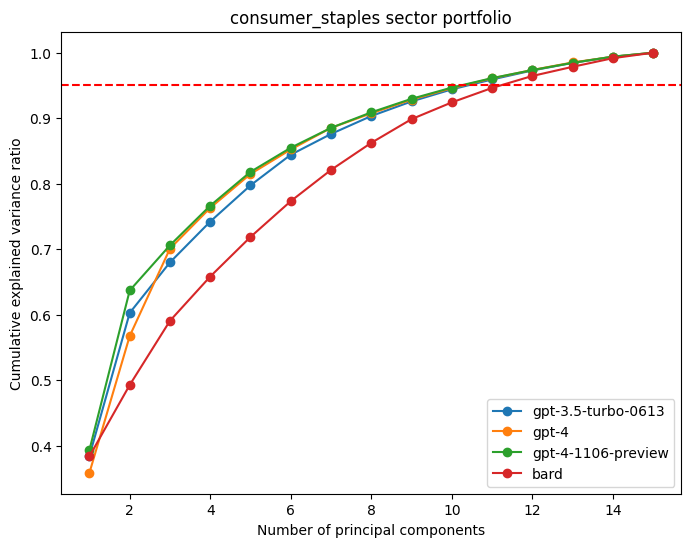

Processing HEALTH_CARE sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.28527837 0.14448053 0.08898924 0.0792388  0.06261461 0.05681115
 0.05242958 0.04346195 0.03851055 0.03470091 0.02918707 0.02502365
 0.02265601 0.01968071 0.01693689]
Effective number of bets:  7.485315345950242
Processing HEALTH_CARE sector, GPT-4 model portfolio
Explained variance ratio:  [0.27315205 0.15972368 0.1114837  0.09864886 0.06026786 0.04903064
 0.04179442 0.03741976 0.03394843 0.03234795 0.02598695 0.02474153
 0.02021196 0.01810032 0.01314188]
Effective number of bets:  7.360391185776239
Processing HEALTH_CARE sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.2644758  0.15718385 0.12865527 0.09419638 0.05718207 0.05260005
 0.04635462 0.04005733 0.03307763 0.03014292 0.026026   0.0231595
 0.01786066 0.01621442 0.01281351]
Effective number of bets:  7.472066919162385
Processing HEALTH_CARE sector, BARD model portfolio
Explained variance ratio:  [0.29760538 0.

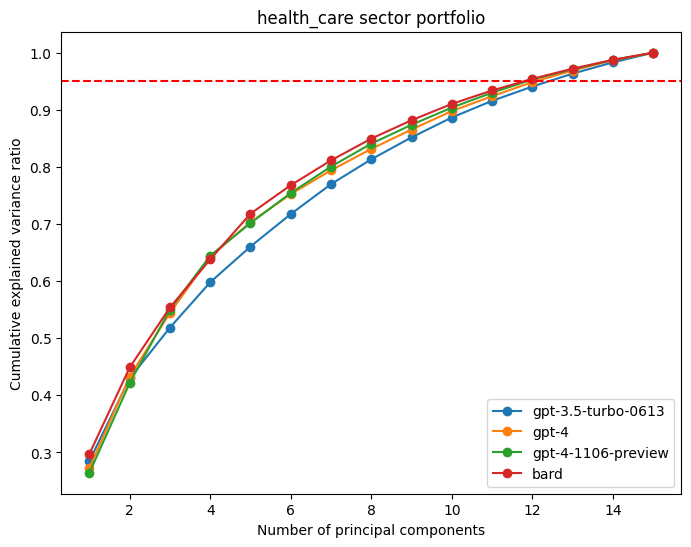

Processing FINANCIALS sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.55721688 0.11259154 0.06924927 0.0671076  0.0407488  0.0382151
 0.02805003 0.01694151 0.01654726 0.01266595 0.01234915 0.00930555
 0.0080328  0.00660419 0.00437438]
Effective number of bets:  2.963299394816771
Processing FINANCIALS sector, GPT-4 model portfolio
Explained variance ratio:  [0.46915159 0.14590317 0.11033517 0.06032952 0.05136307 0.03614211
 0.02760898 0.02289326 0.01721076 0.01514959 0.01281902 0.01102491
 0.00864904 0.00720727 0.00421252]
Effective number of bets:  3.7966323582953314
Processing FINANCIALS sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.51403776 0.12303166 0.09927199 0.05255984 0.04739369 0.03291538
 0.02716364 0.02392427 0.01981399 0.01625398 0.0125669  0.01069283
 0.0086872  0.00759081 0.00409607]
Effective number of bets:  3.358998249204177
Processing FINANCIALS sector, BARD model portfolio
Explained variance ratio:  [0.53760984 0.137

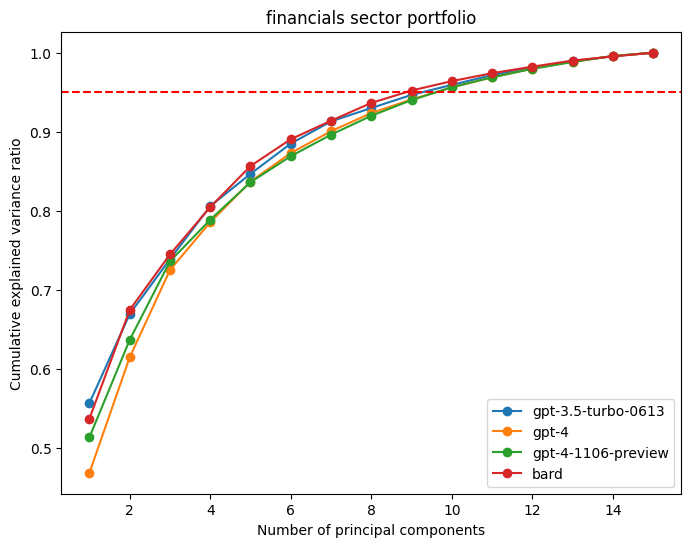

Processing INFORMATION_TECHNOLOGY sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.49887447 0.11194669 0.06761486 0.06330239 0.04708809 0.03980959
 0.03540902 0.03023679 0.02351195 0.02146766 0.01902677 0.01308359
 0.01289017 0.00916415 0.00657381]
Effective number of bets:  3.599749050982664
Processing INFORMATION_TECHNOLOGY sector, GPT-4 model portfolio
Explained variance ratio:  [0.47933717 0.12067581 0.07210528 0.05751514 0.04878634 0.04007336
 0.03600633 0.02824877 0.02387732 0.02075611 0.02026647 0.01824309
 0.01392093 0.01150239 0.0086855 ]
Effective number of bets:  3.8305314768856094
Processing INFORMATION_TECHNOLOGY sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.47933717 0.12067581 0.07210528 0.05751514 0.04878634 0.04007336
 0.03600633 0.02824877 0.02387732 0.02075611 0.02026647 0.01824309
 0.01392093 0.01150239 0.0086855 ]
Effective number of bets:  3.830531476885617
Processing INFORMATION_TECHNOLOGY sector, BARD model portf

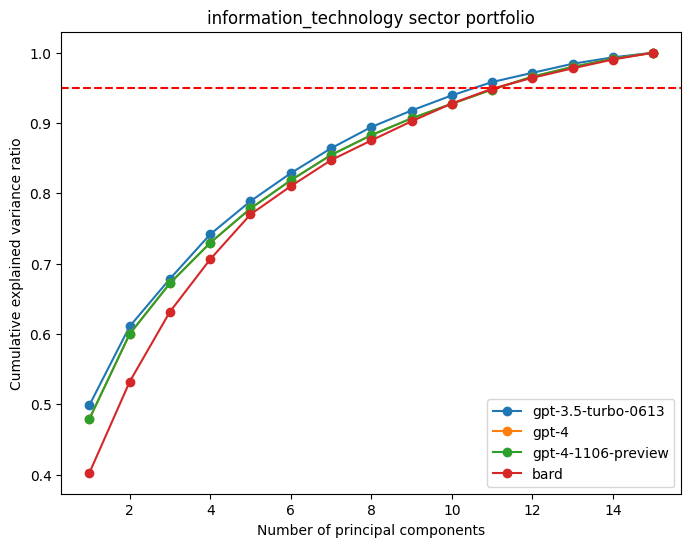

Processing COMMUNICATION_SERVICES sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [3.22045720e-01 1.42959071e-01 1.29262458e-01 1.04495774e-01
 7.81342053e-02 5.92131111e-02 4.67474784e-02 4.11549799e-02
 2.73445126e-02 1.74773462e-02 1.66011787e-02 1.44039291e-02
 1.60235522e-04]
Effective number of bets:  5.995010647803278
Processing COMMUNICATION_SERVICES sector, GPT-4 model portfolio
Explained variance ratio:  [2.99413200e-01 1.45857889e-01 1.33209939e-01 1.03989740e-01
 6.31019573e-02 5.65318138e-02 4.81017444e-02 3.83422127e-02
 2.68375299e-02 2.53539759e-02 1.67528891e-02 1.64747844e-02
 1.41457234e-02 1.17313031e-02 1.55297170e-04]
Effective number of bets:  6.548957777478356
Processing COMMUNICATION_SERVICES sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.29449596 0.13484163 0.11851061 0.1044892  0.08961022 0.05557903
 0.04991195 0.04072355 0.03009556 0.02539746 0.01633816 0.01552491
 0.01349988 0.01098186]
Effective number of bet

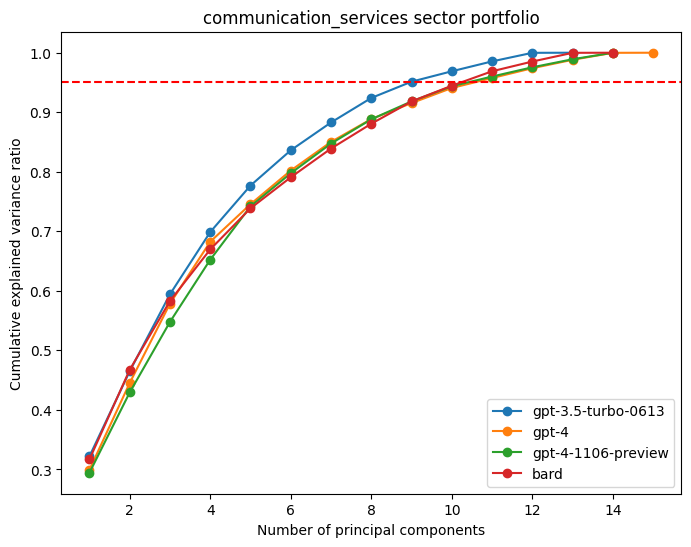

Processing UTILITIES sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.74398717 0.06519552 0.04899066 0.02283389 0.01822897 0.01568861
 0.01429828 0.01333128 0.01190903 0.00977725 0.0086151  0.00828038
 0.00785685 0.00684878 0.00415823]
Effective number of bets:  1.7788670504264044
Processing UTILITIES sector, GPT-4 model portfolio
Explained variance ratio:  [0.73632691 0.06374324 0.04905047 0.02224942 0.02165372 0.01799341
 0.01591793 0.01394281 0.01168591 0.0106072  0.00911418 0.00811455
 0.00702158 0.00680311 0.00577556]
Effective number of bets:  1.8151822901101162
Processing UTILITIES sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.74159088 0.06700798 0.04414121 0.02379239 0.018514   0.01697944
 0.0149993  0.01307555 0.01290839 0.01033197 0.00851493 0.00776337
 0.00749474 0.00711715 0.00576868]
Effective number of bets:  1.7903984179725712
Processing UTILITIES sector, BARD model portfolio
Explained variance ratio:  [0.63135794 0.0961

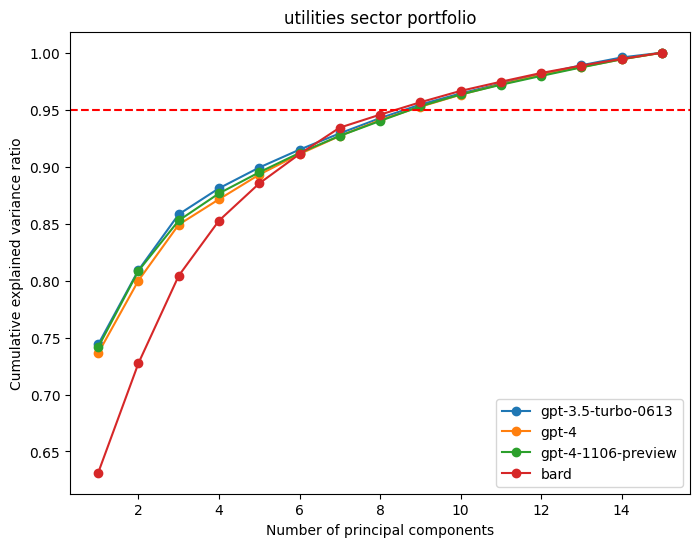

Processing REAL_ESTATE sector, GPT-3.5-TURBO-0613 model portfolio
Explained variance ratio:  [0.5860948  0.0788022  0.07407066 0.05786992 0.04359787 0.03015636
 0.02496267 0.02068974 0.01656235 0.01535699 0.01397955 0.01302573
 0.01140032 0.00834657 0.00508427]
Effective number of bets:  2.7509226751922826
Processing REAL_ESTATE sector, GPT-4 model portfolio
Explained variance ratio:  [0.58750288 0.08329396 0.06419478 0.05293616 0.04128432 0.03581827
 0.0260954  0.02249929 0.0178084  0.01636237 0.01530907 0.01527364
 0.01231478 0.00661876 0.00268793]
Effective number of bets:  2.7438571228358257
Processing REAL_ESTATE sector, GPT-4-1106-PREVIEW model portfolio
Explained variance ratio:  [0.57662711 0.08195725 0.06446687 0.04615332 0.04124014 0.03226351
 0.03117984 0.02405204 0.02171925 0.01891946 0.01735241 0.01550907
 0.01335612 0.01229297 0.00291065]
Effective number of bets:  2.844921341063349
Processing REAL_ESTATE sector, BARD model portfolio
Explained variance ratio:  [0.58802876

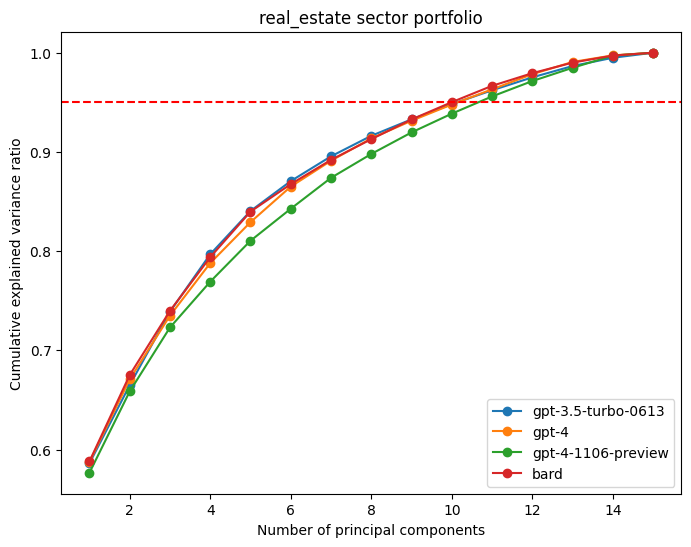

In [12]:
for sector_name in sectors:
    perform_pca(sector_name, 0.95)

## Effective rank of the matrix functions

In [13]:
def erank_function(eigenvalues):
    '''
    e ** H(eigenvalues)
    H is Shannon entropy
    '''
    shannon_entropy_value, n = 0, len(eigenvalues)

    for i, p_i in enumerate(eigenvalues):
        shannon_entropy_value += (p_i * np.log(p_i))

    return np.e ** (-shannon_entropy_value)

In [14]:
def calculate_erank(returns_out_filtered, model, sector_name, write=False):
    returns_covariance_mtx = np.cov(returns_out_filtered)

    eigenvalues = eig(returns_covariance_mtx)[0] # returns eig, eiv
    eigenvalues_st = [(eig/sum(eigenvalues)) for eig in eigenvalues] # standartize
    erank = erank_function(eigenvalues_st)
    
    if write:
        with open('metrics/erank.csv', 'a', encoding='utf-8') as f:
            f.write(f'{model},{sector_name},{np.real(erank)}\n')

    return np.real(erank)

In [15]:
def calculate_erank_github(portfolio, write=False):
    data = yf.download(tickers = portfolio['Stock'].tolist(), period = 'max')
    calculator = EffectiveRankCalculator.EffectiveRankCalculator()
    calculator.calculate(prices=data['Close'])

    calculator.calculate_history(prices=data['Close'])
    calculator.erank_history
        
    if write:
        with open('metrics/erank_calculator_github.csv', 'a', encoding='utf-8') as f:
            f.write(f'{model},{sector_name},{calculator.effectiveRank}\n')

    return calculator.effectiveRank


## Effective number of bets functions

In [16]:
def diagonal_matrix(values):
    n = len(values)
    result = [[0] * n for _ in range(n)]
    
    for i in range(n):
        result[i][i] = values[i]
    
    return np.array(result)

In [17]:
def d(eigval_mtx, returns_covariance_mtx, weights):
    weights = np.array(weights)
    eigval_mtx_T_inverse = inv(eigval_mtx.T)
    
    A = eigval_mtx_T_inverse * weights
    B = eigval_mtx * returns_covariance_mtx * weights

    up = np.multiply(A, B)
    down = weights.T * returns_covariance_mtx * weights
    res = pd.DataFrame(up / down)
    
    return res.astype(np.float64)

In [18]:
def enb_function(d_w):
    '''
    e ** H(eigenvalues)
    H is Shannon entropy
    '''
    shannon_entropy_value, n = 0, len(d_w)

    for i, dw_i in d_w.iterrows():
        dw_i_log = dw_i.apply(lambda x: np.log(x))
        dot_product = np.dot(dw_i, dw_i_log)
        shannon_entropy_value += dot_product
        # shannon_entropy_value += (dw_i * dw_i_log)

    return np.e ** (-shannon_entropy_value)

In [19]:
def get_mean_df(returns_out_filtered):
    num_blocks = 15
    block_size = len(returns_out_filtered) // num_blocks

    result_df = pd.DataFrame(index=range(num_blocks), columns=returns_out_filtered.columns)

    for i in range(num_blocks):
        start_row = i * block_size
        end_row = (i + 1) * block_size
        block = returns_out_filtered.iloc[start_row:end_row]

        mean_values = block.mean(axis=0)
        result_df.iloc[i] = mean_values

    # print(result_df)
    return result_df


In [20]:
def calculate_enb(returns_out_filtered, model, sector_name, write=False):
    weights = portfolio['Weight'].tolist()

    # returns_covariance_mtx_avg = returns_out_filtered.corr() # HEREEEEEEE - expand to 225 randomly + /15
    returns_covariance_mtx_avg = get_mean_df(returns_out_filtered).cov()

    eigenvalues_avg = eig(returns_covariance_mtx_avg)[0]
    eigenvalues_avg = [(eig/sum(eigenvalues_avg)) for eig in eigenvalues_avg] # standartize

    eigval_mtx = diagonal_matrix(eigenvalues_avg)
    d_w = d(eigval_mtx, returns_covariance_mtx_avg, weights)

    # d_w_eig = eig(d_w)[0]
    # enb = erank_function(d_w_eig)
    enb = enb_function(d_w)

    if write:
        with open('metrics/enb.csv', 'a', encoding='utf-8') as f:
            f.write(f'{model},{sector_name},{np.real(enb)}\n')

    return enb


## Calculate ER and ENB sectorwise

In [21]:
def process_sectors(sector_name):
    print(f'{sector_name.upper()} SECTOR')
    for model in models[:1]:
        if model == 'gpt-4':
            csv_path = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == "gpt-4-1106-preview":
            csv_path = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'bard':
            csv_path =  f'bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_path = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_path)

        csv_path = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_out = pd.read_csv(csv_path)
        required_columns = portfolio['Stock'].tolist()
        returns_out_filtered = returns_out.loc[:, required_columns]


        # EFFECTIVE RANK (NO WEIGHTS, RETURNS COVARIANCES)
        erank = calculate_erank(returns_out_filtered, model, sector_name)
        print('my erank: ', erank)



        # EFFECTIVE NUMBER OF BETS (AVG PRICE COVARIENCE, WEIGHTS)
        # enb = calculate_enb(returns_out_filtered, model, sector_name)
        # print('enb: ', enb)



        # GITHUB CALCULATOR FOR ERANK (NO WEIGHTS, HISTORY)
        # erank_github = calculate_erank_github(portfolio)
        # print('erank github: ', erank_github)

        # VENDI SCORE ON SIMILARITY MATRIX
        # sim_mtx = cosine_similarity(returns_out_filtered)
        # print('vendi score: ', vendi.score_K(sim_mtx), '\n')


        # print(f'Processing {sector_name.upper()} sector, {model.upper()} model portfolio')




when we take say CLX 15 times (non diversified portfolio) = rank nan

CLX 14 times + MO = rank 0.99

### erank top

11 companies from different sectors

6.372220531093014

required_columns = ['XOM', 'LIN', 'HON', 'AMZN', 'PG', 'JNJ', 'JPM', 'NVDA', 'META', 'NEE', 'AMT']


In [24]:
sectors

['energy',
 'materials',
 'industrials',
 'consumer_discretionary',
 'consumer_staples',
 'health_care',
 'financials',
 'information_technology',
 'communication_services',
 'utilities',
 'real_estate']

In [35]:
required_columns = ['XOM', 'LIN', 'HON', 'AMZN', 'PG', 'JNJ', 'JPM', 'NVDA', 'META', 'NEE', 'AMT']

returns_out_filtered = pd.DataFrame()

for sect, ticker in zip(sectors[:5], required_columns[:5]):
    csv_path = f'4_returns_outsample/SP500_{sect}_returns_since_Apr2023.csv'
    returns_out = pd.read_csv(csv_path)

    returns_out_filtered[ticker] = returns_out.loc[:, ticker]

# for _ in range(13):
#     returns_out_filtered['CLX' + str(_) + 'Duplicate'] = returns_out_filtered['CLX']

print(returns_out_filtered)

# EFFECTIVE RANK (NO WEIGHTS, RETURNS COVARIANCES)
erank = calculate_erank(returns_out_filtered, 'g', 'name')
print('my erank: ', erank)

          XOM       LIN       HON      AMZN        PG
0   -0.009558 -0.000838 -0.012107  0.015038  0.004816
1    0.017127 -0.006121 -0.007908 -0.027417  0.006856
2   -0.016583  0.002728  0.005437  0.009496  0.006347
3   -0.004433  0.005553  0.006406  0.001078 -0.008277
4    0.007072 -0.000865  0.002661 -0.022022 -0.001987
..        ...       ...       ...       ...       ...
162  0.005384  0.006316  0.005720  0.000204  0.002384
163 -0.005833 -0.003428 -0.002275  0.006747 -0.000925
164 -0.000577 -0.005014  0.006737 -0.004738  0.006943
165 -0.015014  0.001607 -0.000052 -0.004829 -0.007617
166  0.003909  0.005785  0.008545 -0.001572  0.015814

[167 rows x 5 columns]
my erank:  3.027835180044973


In [558]:
for sector_name in sectors[:5]:
    process_sectors(sector_name)

ENERGY SECTOR
my erank:  9.508468974412914
MATERIALS SECTOR
my erank:  9.72383375071626
INDUSTRIALS SECTOR
my erank:  11.556798288059607
CONSUMER_DISCRETIONARY SECTOR
my erank:  8.504144648040947
CONSUMER_STAPLES SECTOR
my erank:  7.692093484090776


## Analyse

In [504]:
ranks = pd.read_csv('metrics/erank.csv')
ranks.sort_values(by='effective_rank', ascending=False)

,model,sector,effective_rank
8,gpt-3.5-turbo-0613,industrials,11.556798
20,gpt-3.5-turbo-0613,health_care,11.503103
42,gpt-4-1106-preview,real_estate,11.129196
9,gpt-4,industrials,10.947972
19,bard,consumer_staples,10.944768
11,bard,industrials,10.878417
10,gpt-4-1106-preview,industrials,10.809188
21,gpt-4,health_care,10.737321
22,gpt-4-1106-preview,health_care,10.548387
7,bard,materials,10.411490


In [372]:
bets = pd.read_csv('metrics/enb.csv')
bets['effective_number_of_bets'] = bets['effective_number_of_bets'].astype(np.float64)
bets.sort_values(by='effective_number_of_bets', ascending=False)

,model,sector,effective_number_of_bets
28,gpt-3.5-turbo-0613,information_technology,1.0
33,gpt-4,communication_services,1.0
23,bard,health_care,1.0
36,gpt-3.5-turbo-0613,utilities,1.0
11,bard,industrials,1.0
42,gpt-4-1106-preview,real_estate,1.0
3,bard,energy,1.0
5,gpt-4,materials,1.0
13,gpt-4,consumer_discretionary,1.0
17,gpt-4,consumer_staples,1.0


## Marketcap

In [41]:
# get the response in the form of html
wikiurl="https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
#table_class="wikitable sortable components"
response=requests.get(wikiurl)
print(response.status_code)

# parse data from the html into a beautifulsoup object
soup = BeautifulSoup(response.text, 'html.parser')
indiatable=soup.find_all('table',{'class':"wikitable"})

df_sp500 = pd.read_html(str(indiatable[0]))
# convert list to dataframe
df_sp500=pd.DataFrame(df_sp500[0])
# print(df_sp500.head())

companies = df_sp500["Symbol"].values
companies

200


array(['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL',
       'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT',
       'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AAL', 'AEP',
       'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI',
       'ANSS', 'AON', 'APA', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM',
       'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB',
       'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BK', 'BBWI', 'BAX', 'BDX',
       'BRK.B', 'BBY', 'BIO', 'TECH', 'BIIB', 'BLK', 'BX', 'BA', 'BKNG',
       'BWA', 'BXP', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF.B', 'BLDR',
       'BG', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL',
       'CARR', 'CTLT', 'CAT', 'CBOE', 'CBRE', 'CDW', 'CE', 'COR', 'CNC',
       'CNP', 'CF', 'CHRW', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB',
       'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME',
       'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CMA', 'CAG', 'COP', 'ED',
  

In [46]:
def market_cap_to_numeric(market_cap_str):
    multiplier = market_cap_str[-1]
    value = float(market_cap_str[:-1])
    
    if multiplier == 'B':
        return value * 1e9
    elif multiplier == 'T':
        return value * 1e12
    else:
        return value


In [59]:
def calculate_marketcap(model, sector_name, df_temp):
    csv_file_path = f'marketcap/{model}_{sector_name}.csv'

    if os.path.exists(csv_file_path):
        print('Reading data from local CSV file...')
        df_GPT_15_mc = pd.read_csv(csv_file_path)    
        
    else:
        print('Scrapping data from the web...')
        url_base = "https://finviz.com/quote.ashx?t="

        tckr = df_temp['Stock'].tolist()

        i = 1

        url_list = [(s, url_base + s) for s in tckr]
        data_list = []

        headers = {'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:76.0) Gecko/20100101 Firefox/76.0'}
        ticker_weight_map = df_temp.set_index('Stock')['Weight'].to_dict()

        for t, url in url_list:
            print(i)
            i = i + 1
            print(t, url)
            print('Scrapping ticker {}...'.format(t))
            soup = BeautifulSoup(requests.get(url, headers=headers).content, 'html.parser')

            l = []
            for row in soup.select('.snapshot-table2 tr'):
                l.append([td.text for td in row.select('td')])
                x = list(chain.from_iterable(l))
                d = dict(zip(x[::2], x[1::2]))
                # print(d)

            # Use the weight from ticker_weight_map instead of 1/len(tckr)
            data_dict = {'Index': t, 'Weight': ticker_weight_map[t], 'Market Cap': d['Market Cap']}
            data_list.append(data_dict)

        df_GPT_15_mc = pd.DataFrame(data_list)
        # Save the DataFrame to a CSV file
        df_GPT_15_mc.to_csv(csv_file_path, index=False)

        print('Data saved to local CSV file.')

In [88]:
for sector_name in sectors:
    for model in models:
        if model == 'gpt-4':
            csv_path = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == "gpt-4-1106-preview":
            csv_path = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'bard':
            csv_path =  f'bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        else:
            csv_path = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        df_temp = pd.read_csv(csv_path)

        calculate_marketcap(model, sector_name, df_temp)

Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV file...
Reading data from local CSV 

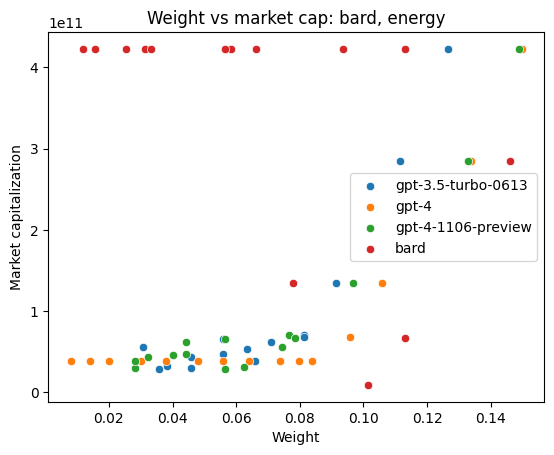

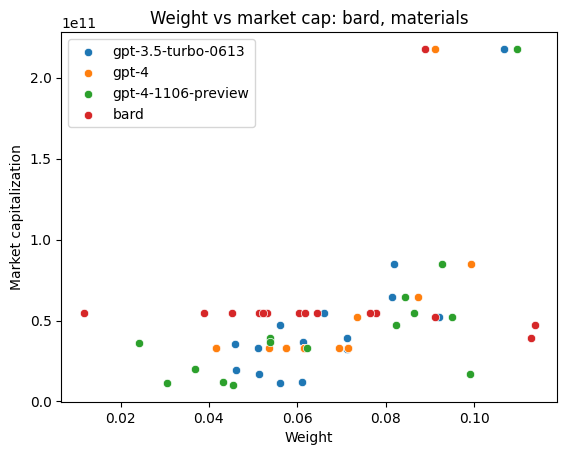

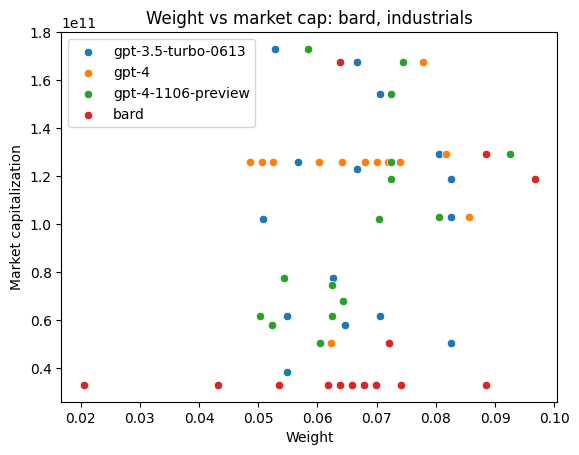

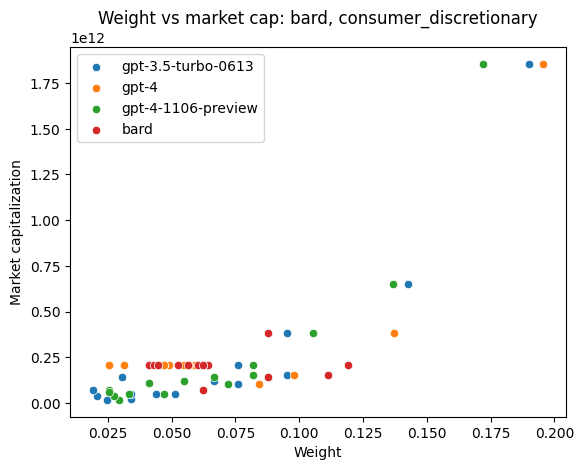

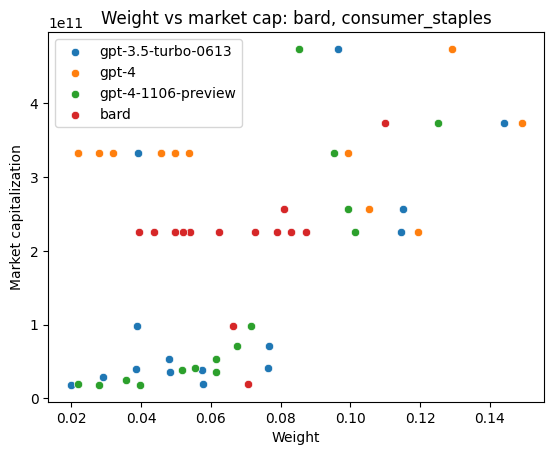

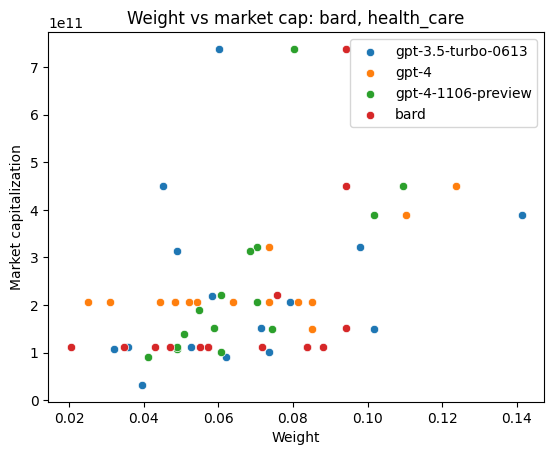

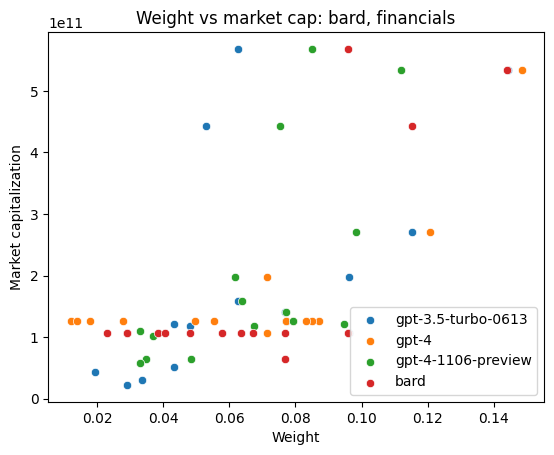

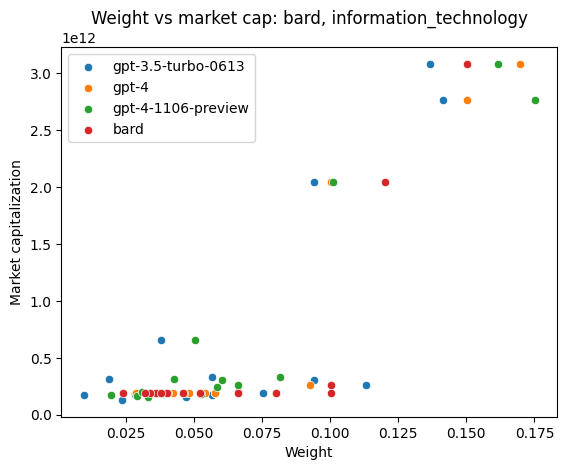

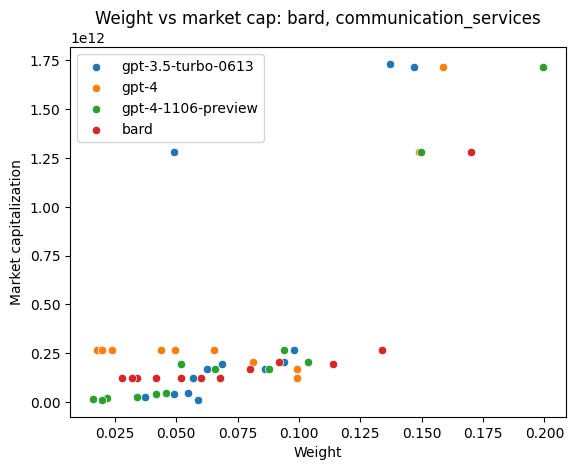

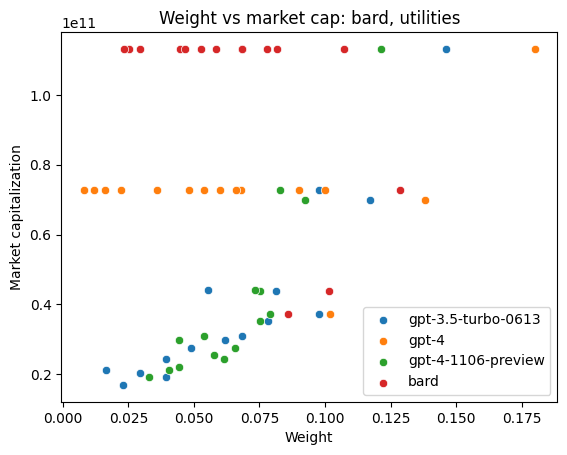

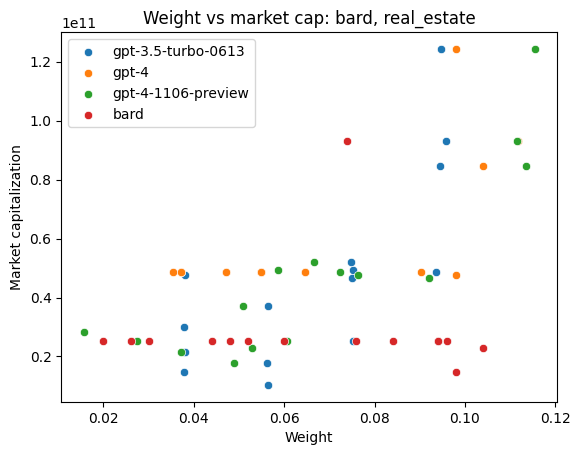

In [101]:
for sector_name in sectors:
    # plt.figure(figsize=(12, 8))
    for model in models:
        csv_path = f'marketcap/{model}_{sector_name}.csv'

        df_mc = pd.read_csv(csv_path)
        df_mc['Market Cap'] = df_mc['Market Cap'].apply(market_cap_to_numeric)

        sns.scatterplot(data=df_mc, x='Weight', y='Market Cap', label=model)
    plt.title(f'Weight vs market cap: {model}, {sector_name}')
    plt.xlabel('Weight')
    plt.ylabel('Market capitalization')
    plt.legend()
    plt.show()


In [110]:
# ['industrials', 'consumer_discretionary', 'financials', 'communication_services']

for sector_name in ['industrials']:
    # plt.figure(figsize=(12, 8))
    for model in models:
        csv_path = f'marketcap/{model}_{sector_name}.csv'

        df_mc = pd.read_csv(csv_path)
        df_mc['Market Cap'] = df_mc['Market Cap'].apply(market_cap_to_numeric)
        print(df_mc.sort_values(by='Weight', ascending=False))

        # sns.scatterplot(data=df_mc, x='Weight', y='Market Cap', label=model)
    # plt.title(f'Weight vs market cap: {model}, {sector_name}')
    # plt.xlabel('Weight')
    # plt.ylabel('Market capitalization')
    # plt.legend()
    # plt.show()


   Index    Weight    Market Cap
3    MMM  0.082493  5.065000e+10
8    RTX  0.082493  1.189000e+11
9    LMT  0.082493  1.028700e+11
1    HON  0.080514  1.291600e+11
5    UNP  0.070623  1.540900e+11
13   FDX  0.070623  6.180000e+10
2    CAT  0.066667  1.677000e+11
4     BA  0.066667  1.229100e+11
10   NSC  0.064688  5.803000e+10
11   ITW  0.062710  7.756000e+10
14   UPS  0.056775  1.258500e+11
6    EMR  0.054797  6.185000e+10
12   CMI  0.054797  3.835000e+10
0     GE  0.052819  1.729500e+11
7     DE  0.050841  1.022900e+11
   Index    Weight    Market Cap
0    LMT  0.085603  1.028700e+11
2    HON  0.081712  1.291600e+11
1    CAT  0.077821  1.677000e+11
5    UNP  0.073930  1.258500e+11
7     DE  0.071984  1.258500e+11
9    RTX  0.071984  1.258500e+11
10   NOC  0.070039  1.258500e+11
4    UPS  0.068093  1.258500e+11
11   FDX  0.064202  1.258500e+11
3    MMM  0.062257  5.065000e+10
6     BA  0.060311  1.258500e+11
12   ITW  0.060311  1.258500e+11
13   EMR  0.052529  1.258500e+11
8     GE  

## Sharpe ratios

In [7]:
## In-sample end date (using 5 years of weekly data prior to end date)
insample_enddate = datetime(2023, 3, 31)

## Out-of-sample period (1 Apr 2023 to 1 Dec 2023) (using daily data))
outsample_startdate = datetime(2023, 4, 1)
outsample_enddate   = datetime(2023, 12,  1)

insample_startdate = insample_enddate - timedelta(weeks=5*52) # five years prior to April 2023

In [8]:
index_tickers = ["^GSPC", "^GSPE", '^SP500-15', '^SP500-20', '^SP500-25', '^SP500-30', '^SP500-35', '^SP500-40',\
                 '^SP500-45', '^SP500-50', '^SP500-55', '^SP500-60']

index_data_outs = pd.DataFrame()

# Download historical data for each index for out-of-sample period 1
for ticker in index_tickers:
    index_df = yf.download(ticker, start=outsample_startdate, end=outsample_enddate, interval='1d')
    index_df['Index_Return'] = index_df['Adj Close'].pct_change()
    index_df.dropna(subset=['Index_Return'], inplace=True)
    index_data_outs[ticker] = index_df['Index_Return']

# Set the index of out-of-sample data to datetime format
index_data_outs.index = pd.to_datetime(index_data_outs.index)

# Create empty lists to store the tickers with continuous data in each out-of-sample period
valid_index_tickers_outs = []

for ticker in index_tickers:
    # Check if the ticker has continuous data in out-of-sample period 1
    if ticker in index_data_outs.columns and index_data_outs[ticker].notna().all():
        valid_index_tickers_outs.append(ticker)


index_tickers = valid_index_tickers_outs

print("Valid Index Tickers in Out-of-Sample Period")
print(valid_index_tickers_outs)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
Valid Index Tickers in Out-of-Sample Period
['^GSPC', '^GSPE', '^SP500-15', '^SP500-20', '^SP500-25', '^SP500-30', '^SP500-35', '^SP500-40', '^SP500-45', '^SP500-50', '^SP5

In [9]:
index_data_outs

,^GSPC,^GSPE,^SP500-15,^SP500-20,^SP500-25,^SP500-30,^SP500-35,^SP500-40,^SP500-45,^SP500-50,^SP500-55,^SP500-60
Date,,,,,,,,,,,,
2023-04-04,-0.005797,-0.017205,-0.014671,-0.022524,-0.000720,-0.002435,0.000236,-0.010124,-0.005819,0.003064,0.005212,0.000859
2023-04-05,-0.002492,0.014207,-0.002223,-0.013005,-0.020381,0.005547,0.017304,-0.001413,-0.011920,-0.002175,0.025721,-0.005064
2023-04-06,0.003579,-0.014716,-0.002189,-0.000254,0.000496,0.000801,0.002252,0.003074,0.006785,0.017072,0.007355,0.006987
2023-04-10,0.000996,0.006466,0.004925,0.008976,0.004249,-0.000140,-0.000372,0.002708,-0.001472,-0.006888,-0.002002,0.005097
2023-04-11,-0.000041,0.008916,0.007282,0.005891,0.000159,0.002413,0.002961,0.008495,-0.010330,-0.004264,0.000650,0.004517
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-24,0.000597,0.004469,0.003326,0.002915,0.001336,0.003824,0.005107,0.003298,-0.003182,-0.006658,0.003042,0.003232
2023-11-27,-0.001954,-0.003968,-0.000844,-0.005792,0.001926,-0.002396,-0.006353,-0.002810,0.000441,-0.004746,0.000948,0.004280
2023-11-28,0.000980,0.000576,0.001963,-0.002420,0.005379,0.004021,-0.005034,-0.001025,0.001912,0.003263,0.003125,0.005800


In [152]:
risk_free_rate = 0.02
risk_free_rate_daily = (1 + risk_free_rate) ** (1/252) - 1

sharpe_ratios = {}
for column in index_data_outs.columns:
    returns = index_data_outs[column]
    average_return = np.mean(returns)
    std_dev = np.std(returns)
    sharpe_ratio = (average_return - risk_free_rate) / std_dev
    sharpe_ratios[column] = sharpe_ratio

sharpe_df = pd.DataFrame.from_dict(sharpe_ratios, orient='index', columns=['Sharpe Ratio'])
sharpe_df.index.name = 'Index'

print(sharpe_df)

            Sharpe Ratio
Index                   
^GSPTSE        -2.737757
^FTSE          -2.924423
DAX            -2.063911
^FCHI          -2.435197
FTSEMIB.MI     -2.126148
^N225          -1.839235
000001.SS      -2.800212


In [11]:
sharpe_df.sort_values(by='Sharpe Ratio', ascending=False)

,Sharpe Ratio
Index,
^SP500-45,0.109505
^SP500-50,0.095659
^GSPC,0.074968
^SP500-25,0.072861
^SP500-40,0.066769
^SP500-20,0.030069
^SP500-15,0.003904
^SP500-60,-0.001071
^SP500-35,-0.007933


In [76]:
for sector_name in sectors:
    for model in models:
        if model == 'gpt-4':
            csv_filename = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-3.5-turbo-0613':
            csv_filename = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-4-1106-preview':
            csv_filename = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_filename)
        stocks_in_portfolio = portfolio['Stock']
        weights = portfolio.sort_values(by='Stock')['Weight']

        csv_filename_returns = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_df = pd.read_csv(csv_filename_returns)
        returns_df = returns_df[stocks_in_portfolio]

        risk_free_rate = 0.05
        risk_free_rate_daily = (1 + risk_free_rate) ** (1/252) - 1  # Convert annual risk-free rate to daily rate

        weighted_returns = returns_df.T * weights
        portfolio_return = weighted_returns.sum(axis=1)

        avg_portfolio_return = np.mean(portfolio_return)
        std_portfolio_return = np.std(portfolio_return)

        # std_portfolio_return = np.sqrt(np.dot(weights, np.dot(np.cov(returns_df), weights)))

        sharpe_ratio = (avg_portfolio_return - risk_free_rate_daily) / std_portfolio_return
        print(sharpe_ratio)

        with open('metrics/sharpe_ratio_5.csv', 'a', encoding='utf-8') as f:
            f.write(f'{sector_name},{model},{sharpe_ratio}\n')

-0.690011455684166
-0.5754751307169527
-0.7007076928788518
-0.7007076928788518
-0.522920249030674
-0.6705028958982313
-0.7936279972942443
-0.7936279972942443
-0.6449758928640542
-1.0380437857312668
-0.7276458946254866
-0.7276458946254866
-0.5386873513595417
-0.580060467265099
-0.5392564681934426
-0.5392564681934426
0.6216955227241346
0.8654003384878038
2.0778553366692107
2.0778553366692107
0.8485593310757371
0.6420147228607415
0.6804203769006165
0.6804203769006165
0.2960956012022341
0.4097715671969941
0.14812775865903702
0.14812775865903702
-1.4007531049766282
-1.3060242064948315
-1.313833480669731
-1.313833480669731
-0.2914425988702251
0.10444906516484732
-0.056327234389172226
-0.056327234389172226
3.2239292174958667
5.104817136981084
3.8373541323199465
3.8373541323199465
-0.09478146741314027
0.10382672015371311
0.1840227088833074
0.1840227088833074


In [74]:
sh = pd.read_csv('metrics/sharpe_ratio.csv')
sh.sort_values(by='sector')

,sector,model,sharpe_ratio
35,communication_services,bard,-0.034795
34,communication_services,gpt-4-1106-preview,-0.034795
33,communication_services,gpt-4,0.141201
32,communication_services,gpt-3.5-turbo-0613,-0.258527
12,consumer_discretionary,gpt-3.5-turbo-0613,-0.512006
13,consumer_discretionary,gpt-4,-0.550295
14,consumer_discretionary,gpt-4-1106-preview,-0.510224
15,consumer_discretionary,bard,-0.510224
19,consumer_staples,bard,2.223941
18,consumer_staples,gpt-4-1106-preview,2.223941


In [77]:
sh = pd.read_csv('metrics/sharpe_ratio_5.csv')
sh.sort_values(by='sector')

,sector,model,sharpe_ratio
35,communication_services,bard,-0.056327
34,communication_services,gpt-4-1106-preview,-0.056327
33,communication_services,gpt-4,0.104449
32,communication_services,gpt-3.5-turbo-0613,-0.291443
12,consumer_discretionary,gpt-3.5-turbo-0613,-0.538687
13,consumer_discretionary,gpt-4,-0.580060
14,consumer_discretionary,gpt-4-1106-preview,-0.539256
15,consumer_discretionary,bard,-0.539256
19,consumer_staples,bard,2.077855
18,consumer_staples,gpt-4-1106-preview,2.077855


In [161]:
countries = ['TSX_Canada', 'FTSE100_UK', 'DAX_Germany', 'CAC40_France', 'MIB_Italy', 'Nikkei_Japan', 'SSE_China', 'IBOVESPA_Brazil']

In [162]:
for country in countries:
    for model in models:
        if model == 'gpt-4':
            csv_filename = f'countries/4_avg_weights_assigned/responses15_auto_{country}.csv'
        elif model == 'gpt-3.5-turbo-0613':
            csv_filename = f'countries/3_avg_weights_assigned/responses15_auto_{country}.csv'
        elif model == 'gpt-4-1106-preview':
            csv_filename = f'countries/4preview_avg_weights_assigned/responses15_auto_{country}.csv'

        portfolio = pd.read_csv(csv_filename)
        stocks_in_portfolio = portfolio['Stock']
        weights = portfolio.sort_values(by='Stock')['Weight']

        csv_filename_returns = f'countries/countries_returns_outsample/{country}_returns_since_Apr2023.csv'
        returns_df = pd.read_csv(csv_filename_returns)
        returns_df = returns_df[stocks_in_portfolio]

        risk_free_rate = 0.02
        risk_free_rate_daily = (1 + risk_free_rate) ** (1/252) - 1  # Convert annual risk-free rate to daily rate

        weighted_returns = returns_df.T * weights
        portfolio_return = weighted_returns.sum(axis=1)

        avg_portfolio_return = np.mean(portfolio_return)
        std_portfolio_return = np.std(portfolio_return)

        # std_portfolio_return = np.sqrt(np.dot(weights, np.dot(np.cov(returns_df), weights)))

        sharpe_ratio = (avg_portfolio_return - risk_free_rate_daily) / std_portfolio_return
        print(sharpe_ratio)

        with open('countries/metrics/sharpe_ratio.csv', 'a', encoding='utf-8') as f:
            f.write(f'{country},{model},{sharpe_ratio}\n')

0.4178773317747493
0.3292847482965271
0.3354426949523143
0.3354426949523143
0.3354426949523143
0.7179801821559689
1.1328307008008163
0.7398459191935901
0.7398459191935901
0.7398459191935901
0.4329331921018109
0.23373073010251216
0.2223859951888653
0.2223859951888653
0.2223859951888653
0.7644100522368695
0.8973867906834193
0.5686471594093524
0.5686471594093524
0.5686471594093524
0.8366201043190883
0.3974379832260685
0.9387202057389787
0.9387202057389787
0.9387202057389787
0.02010403733079091
-0.2730769622495716
-0.12583158916605036
-0.12583158916605036
-0.12583158916605036
1.1323425137391434
0.8223909409622219
0.5584706719797546
0.5584706719797546
0.5584706719797546
0.6030217072502663
0.8131067815694117
0.6215384775875484
0.6215384775875484
0.6215384775875484


In [163]:
sh = pd.read_csv('countries/metrics/sharpe_ratio.csv')
sh.sort_values(by='sharpe_ratio')

,country,model,sharpe_ratio
21,Nikkei_Japan,gpt-4,-0.273077
54,Nikkei_Japan,gpt-4,-0.273077
23,Nikkei_Japan,bard,-0.125832
22,Nikkei_Japan,gpt-4-1106-preview,-0.125832
55,Nikkei_Japan,gpt-4-1106-preview,-0.125832
...,...,...,...
18,MIB_Italy,gpt-4-1106-preview,0.938720
24,SSE_China,gpt-3.5-turbo-0613,1.132343
58,SSE_China,gpt-3.5-turbo-0613,1.132343
34,FTSE100_UK,gpt-4,1.132831


In [164]:
index_tickers = ['^GSPTSE', '^FTSE', 'DAX', '^FCHI', 'FTSEMIB.MI', '^N225', '000001.SS', '^BVSP']

index_data_outs = pd.DataFrame()

# Download historical data for each index for out-of-sample period 1
for ticker in index_tickers:
    index_df = yf.download(ticker, start=outsample_startdate, end=outsample_enddate, interval='1d')
    index_df['Index_Return'] = index_df['Adj Close'].pct_change()
    index_df.dropna(subset=['Index_Return'], inplace=True)
    index_data_outs[ticker] = index_df['Index_Return']

# Set the index of out-of-sample data to datetime format
index_data_outs.index = pd.to_datetime(index_data_outs.index)

# Create empty lists to store the tickers with continuous data in each out-of-sample period
valid_index_tickers_outs = []

for ticker in index_tickers:
    # Check if the ticker has continuous data in out-of-sample period 1
    if ticker in index_data_outs.columns and index_data_outs[ticker].notna().all():
        valid_index_tickers_outs.append(ticker)


index_tickers = valid_index_tickers_outs

print("Valid Index Tickers in Out-of-Sample Period")
print(valid_index_tickers_outs)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
Valid Index Tickers in Out-of-Sample Period
['^GSPTSE']


In [165]:
index_data_outs

,^GSPTSE,^FTSE,DAX,^FCHI,FTSEMIB.MI,^N225,000001.SS,^BVSP
Date,,,,,,,,
2023-04-04,-0.000123,-0.005018,0.002036,-0.000136,-0.005593,0.003522,0.004902,0.003576
2023-04-05,-0.005731,0.003720,-0.010498,-0.003902,-0.005920,-0.016762,NaN,-0.008747
2023-04-06,0.001840,0.010270,0.010951,0.001155,0.012915,-0.012247,0.000021,-0.001545
2023-04-10,0.003917,NaN,-0.003385,NaN,NaN,0.004192,-0.003693,0.010166
2023-04-11,0.007206,0.005697,0.004416,0.008946,0.011465,0.010484,-0.000540,0.042878
...,...,...,...,...,...,...,...,...
2023-11-24,-0.000676,0.000615,0.012015,0.002043,0.006704,0.005193,-0.006821,-0.008169
2023-11-27,-0.003502,-0.003672,-0.004749,-0.003745,-0.003058,-0.005289,-0.003049,0.001123
2023-11-28,0.000205,-0.000737,0.005453,-0.002114,0.001193,-0.001174,0.002259,0.006803


In [166]:
risk_free_rate = 0.02
risk_free_rate_daily = (1 + risk_free_rate) ** (1/252) - 1

sharpe_ratios = {}
for column in index_data_outs.columns:
    returns = index_data_outs[column]
    average_return = np.mean(returns)
    std_dev = np.std(returns)
    sharpe_ratio = (average_return - risk_free_rate_daily) / std_dev
    sharpe_ratios[column] = sharpe_ratio

sharpe_df = pd.DataFrame.from_dict(sharpe_ratios, orient='index', columns=['Sharpe Ratio'])
sharpe_df.index.name = 'Index'

print(sharpe_df.sort_values(by='Sharpe Ratio'))

            Sharpe Ratio
Index                   
000001.SS      -0.102563
^FTSE          -0.032199
^GSPTSE        -0.008817
^FCHI          -0.001002
DAX             0.014819
FTSEMIB.MI      0.060215
^N225           0.079966
^BVSP           0.124528


In [66]:
v = pd.read_csv('countries/metrics/volatilities.csv')
v
# sh.sort_values(by='volatility')

,country,gpt4,gpt3,gpt4pre
0,TSX_Canada,0.00575,0.00597,0.00295
1,FTSE100_UK,0.00489,0.00233,0.00346
2,DAX_Germany,0.00747,0.00976,0.00568
3,CAC40_France,0.00765,0.01682,0.00981
4,TSX_Canada,0.00506,0.00592,0.00426
5,FTSE100_UK,0.00489,0.00233,0.00346
6,CAC40_France,0.00765,0.01682,0.00981
7,MIB_Italy,0.02079,0.02155,0.01573
8,Nikkei_Japan,0.00651,0.01440,0.00310
9,SSE_China,0.03479,0.03293,0.01941


## Sharpe ratios for every sector portfolio

In [160]:
def calculate_sharpe_ratio(returns_df, weights):
    risk_free_rate = 0.02
    risk_free_rate_daily = (1 + risk_free_rate) ** (1/252) - 1  # Convert annual risk-free rate to daily rate

    weighted_returns = returns_df.T * weights
    portfolio_return = weighted_returns.sum(axis=1)
    avg_portfolio_return = np.mean(portfolio_return)
    std_portfolio_return = np.std(portfolio_return)

    sharpe_ratio = (avg_portfolio_return - risk_free_rate_daily) / std_portfolio_return
        
    return sharpe_ratio

In [158]:
model_names = ['gpt-4', 'gpt-3', 'gpt-4_preview', 'bard', 'claude']

In [159]:
for sector_name in sectors:
    with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
        f.write(f'{sector_name},')

    for model in model_names:
        if model == 'gpt-4':
            csv_filename = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-3':
            csv_filename = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-4_preview':
            csv_filename = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_filename)
        stocks_in_portfolio = portfolio['Stock']
        weights = portfolio.sort_values(by='Stock')['Weight']
        n = len(stocks_in_portfolio)
        weights_equal = np.array([1/n for _ in range(n)]).reshape(n,1)

        csv_filename_returns = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_df = pd.read_csv(csv_filename_returns)
        returns_df_portfolio = returns_df[stocks_in_portfolio].sort_index(axis=1)

        path_minvar = f'efficient_portfolios/{model}_{sector_name}_minvar_bounded.csv'
        df_minvar = pd.read_csv(path_minvar, header=None).transpose()
        df_minvar.columns = ['Stock', 'Weight']
        df_minvar = df_minvar.sort_values(by='Stock')
        weights_minvar = np.array(df_minvar['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_minvar),1)
        returns_df_minvar = returns_df[df_minvar['Stock']].sort_index(axis=1)

        path_maxret = f'efficient_portfolios/{model}_{sector_name}_maxret_bounded.csv'
        df_maxret = pd.read_csv(path_maxret, header=None).transpose()
        df_maxret.columns = ['Stock', 'Weight']
        df_maxret = df_maxret.sort_values(by='Stock')
        weights_maxret = np.array(df_maxret['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_maxret),1)
        returns_df_maxret = returns_df[df_maxret['Stock']].sort_index(axis=1)

        path_maxsharpe = f'efficient_portfolios/{model}_{sector_name}_maxsharpe_bounded.csv'
        df_maxsharpe = pd.read_csv(path_maxsharpe, header=None).transpose()
        df_maxsharpe.columns = ['Stock', 'Weight']
        df_maxsharpe = df_maxsharpe.sort_values(by='Stock')
        weights_maxsharpe = np.array(df_maxsharpe['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_maxsharpe),1)
        returns_df_maxsharpe = returns_df[df_maxsharpe['Stock']].sort_index(axis=1)


        sharpe_ratio_weighted = calculate_sharpe_ratio(returns_df_portfolio, weights)
        sharpe_ratio_equal = calculate_sharpe_ratio(returns_df_portfolio, weights_equal)
        sharpe_ratio_minvar = calculate_sharpe_ratio(returns_df_minvar, weights_minvar)
        sharpe_ratio_maxret = calculate_sharpe_ratio(returns_df_maxret, weights_maxret)
        sharpe_ratio_maxsharpe = calculate_sharpe_ratio(returns_df_maxsharpe, weights_maxsharpe)

        print(sector_name, model, sharpe_ratio_weighted, 'llm weighted')
        print(sector_name, model, sharpe_ratio_equal, 'equally weighted')
        print(sector_name, model, sharpe_ratio_minvar, 'minvar')
        print(sector_name, model, sharpe_ratio_maxret, 'maxret')
        print(sector_name, model, sharpe_ratio_maxsharpe, 'max sharpe')

        with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
            f.write(f'{sharpe_ratio_weighted},{sharpe_ratio_equal},{sharpe_ratio_minvar},{sharpe_ratio_maxret},{sharpe_ratio_maxsharpe},')
    with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
        f.write('\n')


energy gpt-4 -288.86012974427223 llm weighted
energy gpt-4 -131.3028883904118 equally weighted
energy gpt-4 -83.01172716543519 minvar
energy gpt-4 -125.25373553517649 maxret
energy gpt-4 -124.51046619123498 max sharpe
energy gpt-3 -300.23740332480264 llm weighted
energy gpt-3 -120.19171950054381 equally weighted
energy gpt-3 -73.82639119506499 minvar
energy gpt-3 -116.4229911566294 maxret
energy gpt-3 -88.64119271087938 max sharpe
energy gpt-4_preview -290.60677220321327 llm weighted
energy gpt-4_preview -124.53626450151954 equally weighted
energy gpt-4_preview -74.22604296417227 minvar
energy gpt-4_preview -123.97034461437167 maxret
energy gpt-4_preview -92.25114500142615 max sharpe
energy bard -290.60677220321327 llm weighted
energy bard -124.53626450151954 equally weighted
energy bard -86.4178298131125 minvar
energy bard -135.60605731501772 maxret
energy bard -125.55048733315743 max sharpe
energy claude -290.60677220321327 llm weighted
energy claude -124.53626450151954 equally weigh

## Cumulative returns for every sector portfolio

In [ ]:
for sector_name in sectors:
    with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
        f.write(f'{sector_name},')

    for model in model_names:
        if model == 'gpt-4':
            csv_filename = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-3':
            csv_filename = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
        elif model == 'gpt-4_preview':
            csv_filename = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'

        portfolio = pd.read_csv(csv_filename)
        stocks_in_portfolio = portfolio['Stock']
        weights = portfolio.sort_values(by='Stock')['Weight']
        n = len(stocks_in_portfolio)
        weights_equal = np.array([1/n for _ in range(n)]).reshape(n,1)

        csv_filename_returns = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'
        returns_df = pd.read_csv(csv_filename_returns)
        returns_df_portfolio = returns_df[stocks_in_portfolio].sort_index(axis=1)

        path_minvar = f'efficient_portfolios/{model}_{sector_name}_minvar_bounded.csv'
        df_minvar = pd.read_csv(path_minvar, header=None).transpose()
        df_minvar.columns = ['Stock', 'Weight']
        df_minvar = df_minvar.sort_values(by='Stock')
        weights_minvar = np.array(df_minvar['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_minvar),1)
        returns_df_minvar = returns_df[df_minvar['Stock']].sort_index(axis=1)

        path_maxret = f'efficient_portfolios/{model}_{sector_name}_maxret_bounded.csv'
        df_maxret = pd.read_csv(path_maxret, header=None).transpose()
        df_maxret.columns = ['Stock', 'Weight']
        df_maxret = df_maxret.sort_values(by='Stock')
        weights_maxret = np.array(df_maxret['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_maxret),1)
        returns_df_maxret = returns_df[df_maxret['Stock']].sort_index(axis=1)

        path_maxsharpe = f'efficient_portfolios/{model}_{sector_name}_maxsharpe_bounded.csv'
        df_maxsharpe = pd.read_csv(path_maxsharpe, header=None).transpose()
        df_maxsharpe.columns = ['Stock', 'Weight']
        df_maxsharpe = df_maxsharpe.sort_values(by='Stock')
        weights_maxsharpe = np.array(df_maxsharpe['Weight'].apply(lambda x: float(x)).tolist()).reshape(len(df_maxsharpe),1)
        returns_df_maxsharpe = returns_df[df_maxsharpe['Stock']].sort_index(axis=1)


        sharpe_ratio_weighted = calculate_sharpe_ratio(returns_df_portfolio, weights)
        sharpe_ratio_equal = calculate_sharpe_ratio(returns_df_portfolio, weights_equal)
        sharpe_ratio_minvar = calculate_sharpe_ratio(returns_df_minvar, weights_minvar)
        sharpe_ratio_maxret = calculate_sharpe_ratio(returns_df_maxret, weights_maxret)
        sharpe_ratio_maxsharpe = calculate_sharpe_ratio(returns_df_maxsharpe, weights_maxsharpe)

        print(sector_name, model, sharpe_ratio_weighted, 'llm weighted')
        print(sector_name, model, sharpe_ratio_equal, 'equally weighted')
        print(sector_name, model, sharpe_ratio_minvar, 'minvar')
        print(sector_name, model, sharpe_ratio_maxret, 'maxret')
        print(sector_name, model, sharpe_ratio_maxsharpe, 'max sharpe')

        with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
            f.write(f'{sharpe_ratio_weighted},{sharpe_ratio_equal},{sharpe_ratio_minvar},{sharpe_ratio_maxret},{sharpe_ratio_maxsharpe},')
    with open('metrics/sharpe_ratios_all.csv', 'a', encoding='utf-8') as f:
        f.write('\n')


# drafts

In [91]:
enob = 1 / np.sum(np.square(explained_variance_ratio))
print("Effective Number of Bets (ENOB):", enob)

Effective Number of Bets (ENOB): 2.1539990490673255


A lower ENB value indicates a more concentrated portfolio, where a few assets dominate the variance.

A higher ENB value indicates a more diversified portfolio, where the assets contribute more evenly to the variance.

1 <= ENB <= 15


In [92]:
# Compute risk exposure of each asset to each principal component
risk_exposures = np.abs(pca.components_)

# Compute total risk of each asset
asset_total_risks = np.sqrt(np.sum(risk_exposures**2, axis=0))

# Assign weights based on risk contribution
portfolio_weights = asset_total_risks / np.sum(asset_total_risks)
portfolio_weights

array([0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667,
       0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667,
       0.06666667, 0.06666667, 0.06666667, 0.06666667, 0.06666667])


## 2. Effective Number of Bets
A portfolio is a combination of $n$ correlated assets, and the portfolio return is a weighted average of the return of each asset $R = \Sigma^{n}_{i=1} w_i R_i$, where $w_i$ is the weight of $i$-th asset. 

More in general, a portfolio is a combination of $k$ correlated factors, for instance, Fama-French Five Factors model. Thus, the portfolio return is a combination of the return of each factor:
$$
R = \sum_{i=1}^k b_i F_i
$$
where $b_i$ is the exposure of $i$-th factor 

But if we run a linear regression to obtain the factor-based portfolio return, it would cause a problem: co-linearity for the reason that those factors are correlated. 

In order to solve this problem, we aspire to have a portfolio which is a combination of uncorrelated factors:
$$
R=\sum_{i=1}^k \tilde{b}_i \tilde{F}_i
$$
where $\Bbb{Cr} (\tilde{F}_i, \tilde{F}_j)=0$ if $ i \neq j$. ($\Bbb{Cr}$ denotes the correlation.)

Then, we can compute the Diversification Distribution, namely true relative contributions to total risk from each bet. For $i=1,2,...,k$,
$$
p_i =\frac {\Bbb{V}( \tilde{b}_i \tilde{F}_i)}{\Bbb{V}(R)}
$$
where $\Bbb{V}$ denotes the variance. Note that for any distribution, $p_i$ sums up to $1$ and non-negative.

If $p_1=p_2=...=p_k$, the risk parity is achieved, or the portfolio is well diversified. To quantify diversification, we use the exponential of the entropy that measures the uniformity of a distribution. We define the **Effective Number of Bets** as follows:
$$
\Bbb{N}=e^{-\sum_{i=1}^k p_i * ln(p_i)}
$$
In the case of full concentration, let's say, one factor represents all the risks, the entropy would be $0$, and the Effective Number of Bets would be $1$. Oppositely, in the case of full diversification, each factor represents equal risk contribution, then the Effective Number of Bets would $k$. In general, $1 \leq \Bbb{N} \leq k$.

​    

## 3. Principle Components Bets

In order to construct a portfolio as a combination of uncorrelated factors, a natural start point is principle components analysis on the original factors $\bf{F}$. 

Basically, to perform PCA:
$$
\bf{\Sigma_{F}} = eDe^T
$$
where the covariance of the original factors $\Bbb{Cv}(\bf{F})=\Sigma_{\bf{F}}$. Performing PCA decomposition, we obtain $\bf{D}$ and $\bf{e}$, where $\bf{D}$ is the diagonal matrix of eigenvalues of $\bf{\Sigma_{F}}$, and $\bf{e}$ is the matrix whose columns are eigenvectors of $\bf{\Sigma_{F}}$. 

$\bf{e}$ is orthogonal, that is, $\bf{e}^T\bf{e}=\bf{e}\bf{e}^T=I$. 

Therefore, we have
$$
\bf{\tilde{F}_{PC}}=e^T F
$$

$$
\bf{\tilde{b}_{PC}} =e^T b
$$

$$
\bf{R}=b^T F ={\tilde{b}_{PC}^T} \tilde{F}_{PC} = b^Tee^TF
$$

Then given the exposures $\bf{b}$, we can compute the **Principal Components Diversification Distribution** and the **Effective Number of Principal Components Bets**:
$$
\bf{p}_{PC}(b)=\frac {(e^T b) \cdot (e^T \Sigma_{F} b)} {b^T \Sigma_{F} b}
$$

$$
\Bbb{N}_{PC}({\bf{b}})=e^{-{\bf{p}_{PC}(b)^T \, ln(p_{PC}(b))}}
$$

where $\cdot$ is element-wise product. 

However,  PCA suffers some innate flaws: 

First, principal components are usually uninterpretable. 

Second, principle components are not unique. For instance, $e_i$ is $i$-th eigenvector, so is $-e_i$.

Third, principal components would not be coherent with its simple scale transformations.

In [122]:
"""
Created on Sat May 13 01:30:50 2017

@author: Hao Guo
"""
def torsion(Sigma, model, method='exact', max_niter=10000):
    n = Sigma.shape[0]    
    
    if model == 'pca':
        eigval, eigvec = linalg.eig(Sigma)
        idx = np.argsort(-eigval) 
        t = eigvec[:,idx]
        
    elif model == 'minimum-torsion':
        # C: correlation matrix
        sigma = np.sqrt(np.diag(Sigma))
        C = np.asmatrix(np.diag(1.0/sigma)) * np.asmatrix(Sigma) * np.asmatrix(np.diag(1.0/sigma))
        # Riccati root of correlation matrix
        c = sqrtm(C)
        if method == 'approximate':
            t = (np.asmatrix(sigma) / np.asmatrix(c)) * np.asmatrix(np.diag(1.0/sigma))
        elif method == 'exact':
            # initialize
            d = np.ones((n))
            f = np.zeros((max_niter))
            # iterating
            for i in range(max_niter):
                U = np.asmatrix(np.diag(d)) * c * c * np.asmatrix(np.diag(d))
                u = sqrtm(U)
                q = linalg.inv(u) * np.asmatrix(np.diag(d)) * c
                d = np.diag(q * c)
                pi = np.asmatrix(np.diag(d)) * q
                f[i] = linalg.norm(c - pi, 'fro')
                # if converge
                if i > 0 and abs(f[i]-f[i-1])/f[i] <= 1e-4:
                    f = f[0:i]
                    break
                elif i == max_niter and abs(f[max_niter]-f[max_niter-1])/f[max_niter] >= 1e-4:
                    print('number of max iterations reached: n_iter = ' + str(max_niter))
            x = pi * linalg.inv(np.asmatrix(c))
            t = np.asmatrix(np.diag(sigma)) * x * np.asmatrix(np.diag(1.0/sigma))
    return t

In [123]:
data = returns_out_filtered
ret = np.log(returns_out_filtered/returns_out_filtered.shift(1)).dropna()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/internals/blocks.py:329: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/internals/blocks.py:329: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [124]:
def EffectiveBets(w, Sigma, t):
    w = np.asmatrix(w)
    p = np.asmatrix(np.asarray(linalg.inv(t.T) * w.T) * np.asarray(t * Sigma * w.T)) / (w * Sigma * w.T)  
    enb = np.exp(- p.T * np.log(p))
    return p, enb

In [127]:
"""
Created on Sat May 13 22:26:50 2017

@author: Hao Guo
"""
obs_window = 57
roll_window = 30
T = int((len(data) - obs_window)/10) # number of windows
N = ret.shape[1] # number of stocks
print(N, T)

p_pc = np.asmatrix(np.zeros((N,T)))
p_mt = np.asmatrix(np.zeros((N,T)))
enb_pc = np.zeros(T)
enb_mt = np.zeros(T)
margin_risk = np.asmatrix(np.zeros((N,T)))

for t in range(T):
    Sigma = np.asmatrix(np.cov(ret.iloc[t*roll_window:t*roll_window+obs_window].T))
    w = portfolio['Weight']
    t_pc = torsion(Sigma, 'pca')
    t_mt = torsion(Sigma, 'minimum-torsion',  method='exact')
    p_pc[:,t], enb_pc[t] = EffectiveBets(w, Sigma, t_pc)
    p_mt[:,t], enb_mt[t] = EffectiveBets(w, Sigma, t_mt)
    margin_risk[:,t] = w.reshape((N,1)) * np.asarray(np.asmatrix(Sigma)*np.asmatrix(w).T) \
                       / (np.asmatrix(w) * np.asmatrix(Sigma) * np.asmatrix(w).T)
    

import plotly
from plotly.graph_objs import Surface

plotly.offline.plot([
    dict(z=np.sort(p_mt,axis=0)[::-1], type='surface'),
    dict(z=np.tile(np.asmatrix(w),(T,1)).T, showscale=False, opacity=0.9, type='surface')])
'''

plotly.offline.plot([
    dict(z=np.sort(p_pc,axis=0)[::-1], type='surface'),
    dict(z=np.tile(np.asmatrix(w),(T,1)).T, showscale=False, opacity=0.9, type='surface')])

plotly.offline.plot([
    dict(z=np.sort(margin_risk,axis=0)[::-1], type='surface'),
    dict(z=np.tile(np.asmatrix(w),(T,1)).T, showscale=False, opacity=0.9, type='surface')])
'''

15 11


/var/folders/5j/dtbtysr93p94g67dwcq9gx9m0000gn/T/ipykernel_1599/2145202948.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  p_pc[:,t], enb_pc[t] = EffectiveBets(w, Sigma, t_pc)


ValueError: setting an array element with a sequence.